In [1]:
import duckdb

conn = duckdb.connect()

# Path disesuaikan dengan folder sub-ekstrak 'gen z dataset'
query = """
SELECT * 
FROM '../data/raw/gen z dataset/genz_social_media_usage_1M.csv' 
LIMIT 5
"""

df_preview = conn.execute(query).df()
df_preview

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

,age,gender,country,daily_usage_hours,primary_platform,num_platforms_used,purpose,avg_session_minutes,night_usage,mental_health_score,addiction_level,screen_time_before_sleep
0,19,Male,Australia,2.658617,Snapchat,4,Education,29.222443,0,6.705830,Medium,15.779443
1,16,Female,USA,5.685387,Twitter,3,Socializing,32.464726,1,6.633111,High,47.714864
2,25,Female,India,2.782420,TikTok,2,Socializing,18.170204,1,6.035397,Medium,62.524625
3,27,Male,India,3.486598,YouTube,4,Education,22.493804,1,8.110861,Medium,31.935102
4,23,Female,India,3.748829,TikTok,1,Entertainment,27.358410,1,6.658598,Medium,29.466046


In [2]:
# Buat file parquet untuk efisiensi I/O ke depannya
parquet_path = "../data/raw/genz_social_media_usage_1M.parquet"

conn.execute(f"""
    COPY (
        SELECT * 
        FROM '../data/raw/gen z dataset/genz_social_media_usage_1M.csv'
    ) 
    TO '{parquet_path}' (FORMAT PARQUET)
""")

print("Konversi ke Parquet selesai!")

Konversi ke Parquet selesai!


In [3]:
# Cek total baris dan deteksi nilai NULL di seluruh kolom
null_check_query = """
SELECT 
    COUNT(*) AS total_rows,
    COUNT(*) - COUNT(age) AS null_age,
    COUNT(*) - COUNT(daily_usage_hours) AS null_daily_hours,
    COUNT(*) - COUNT(avg_session_minutes) AS null_avg_session,
    COUNT(*) - COUNT(screen_time_before_sleep) AS null_screen_time_sleep,
    COUNT(*) - COUNT(mental_health_score) AS null_mental_score
FROM '../data/raw/genz_social_media_usage_1M.parquet'
"""

conn.execute(null_check_query).df()

,total_rows,null_age,null_daily_hours,null_avg_session,null_screen_time_sleep,null_mental_score
0,1000000,0,0,0,0,0


In [4]:
stats_query = """
SELECT 
    ROUND(AVG(daily_usage_hours), 2) AS avg_daily_hours,
    MIN(daily_usage_hours) AS min_daily_hours,
    MAX(daily_usage_hours) AS max_daily_hours,
    ROUND(AVG(avg_session_minutes), 2) AS avg_session_min,
    MIN(avg_session_minutes) AS min_session_min,
    MAX(avg_session_minutes) AS max_session_min,
    ROUND(AVG(screen_time_before_sleep), 2) AS avg_sleep_screentime,
    ROUND(AVG(num_platforms_used), 2) AS avg_platforms,
    ROUND(AVG(night_usage) * 100, 2) AS pct_night_users
FROM '../data/raw/genz_social_media_usage_1M.parquet'
"""

df_stats = conn.execute(stats_query).df()
df_stats

,avg_daily_hours,min_daily_hours,max_daily_hours,avg_session_min,min_session_min,max_session_min,avg_sleep_screentime,avg_platforms,pct_night_users
0,3.51,0.5,10.0,25.09,5.0,80.262224,40.12,3.0,60.0


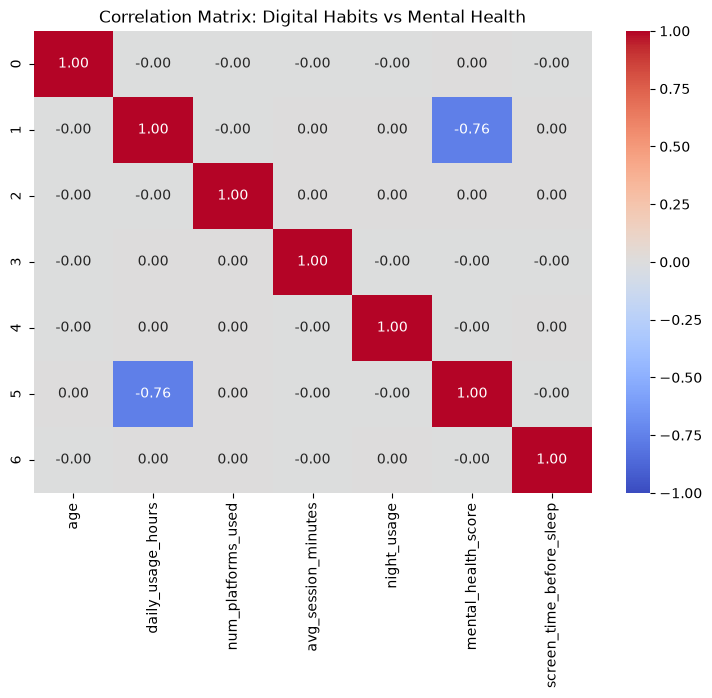

In [5]:
import polars as pl
import seaborn as sns
import matplotlib.pyplot as plt

# Muat data numerik ke DataFrame Polars
numeric_cols = [
    'age', 'daily_usage_hours', 'num_platforms_used', 
    'avg_session_minutes', 'night_usage', 'mental_health_score', 
    'screen_time_before_sleep'
]

df = pl.read_parquet('../data/raw/genz_social_media_usage_1M.parquet', columns=numeric_cols)

# Hitung korelasi Pearson
corr_matrix = df.corr()

# Visualisasikan Heatmap
plt.figure(figsize=(9, 6))
sns.heatmap(corr_matrix.to_pandas(), annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title("Correlation Matrix: Digital Habits vs Mental Health")
plt.show()

In [6]:
feature_query = """
SELECT 
    daily_usage_hours,
    avg_session_minutes,
    num_platforms_used,
    night_usage,
    screen_time_before_sleep,
    ROUND((daily_usage_hours * 60) / NULLIF(avg_session_minutes, 0), 2) AS session_frequency,
    ROUND((screen_time_before_sleep / NULLIF(daily_usage_hours * 60, 0)) * 100, 2) AS night_sleep_ratio,
    mental_health_score,
    addiction_level,
    age,
    country
FROM '../data/raw/genz_social_media_usage_1M.parquet'
"""

df_features = conn.execute(feature_query).df()
df_features.head()

,daily_usage_hours,avg_session_minutes,num_platforms_used,night_usage,screen_time_before_sleep,session_frequency,night_sleep_ratio,mental_health_score,addiction_level,age,country
0,2.658617,29.222443,4,0,15.779443,5.46,9.89,6.705830,Medium,19,Australia
1,5.685387,32.464726,3,1,47.714864,10.51,13.99,6.633111,High,16,USA
2,2.782420,18.170204,2,1,62.524625,9.19,37.45,6.035397,Medium,25,India
3,3.486598,22.493804,4,1,31.935102,9.30,15.27,8.110861,Medium,27,India
4,3.748829,27.358410,1,1,29.466046,8.22,13.10,6.658598,Medium,23,India


In [7]:
from sklearn.preprocessing import StandardScaler

# Fitur murni perilaku
clustering_features = [
    'daily_usage_hours',
    'avg_session_minutes',
    'num_platforms_used',
    'night_usage',
    'screen_time_before_sleep',
    'session_frequency',
    'night_sleep_ratio'
]

# Normalisasi data numerik
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features[clustering_features])

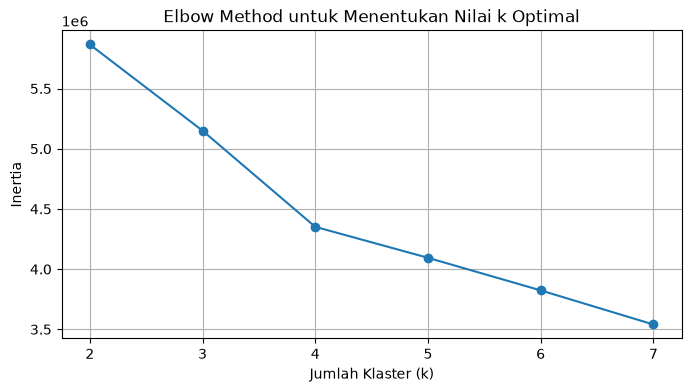

In [8]:
from sklearn.cluster import MiniBatchKMeans

inertia = []
k_range = range(2, 8)

for k in k_range:
    kmeans = MiniBatchKMeans(n_clusters=k, batch_size=4096, random_state=42, n_init=3)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, inertia, marker='o')
plt.xlabel("Jumlah Klaster (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method untuk Menentukan Nilai k Optimal")
plt.grid(True)
plt.show()

In [9]:
# Latih model final dengan k=4
final_kmeans = MiniBatchKMeans(n_clusters=4, batch_size=4096, random_state=42, n_init=5)
df_features['cluster'] = final_kmeans.fit_predict(X_scaled)

# Tampilkan sebaran jumlah pengguna di tiap klaster
print(df_features['cluster'].value_counts(normalize=True).mul(100).round(2).rename("Persentase (%)"))

cluster
3    45.32
0    31.85
1    11.98
2    10.86
Name: Persentase (%), dtype: float64


In [10]:
# Profiling fitur perilaku dan validasi psikologis per klaster
cluster_profile = df_features.groupby('cluster').agg({
    'daily_usage_hours': 'mean',
    'avg_session_minutes': 'mean',
    'session_frequency': 'mean',
    'screen_time_before_sleep': 'mean',
    'night_sleep_ratio': 'mean',
    'night_usage': 'mean',
    'num_platforms_used': 'mean',
    'mental_health_score': 'mean'
}).round(2)

cluster_profile

,daily_usage_hours,avg_session_minutes,session_frequency,screen_time_before_sleep,night_sleep_ratio,night_usage,num_platforms_used,mental_health_score
cluster,,,,,,,,
0,3.65,27.09,8.82,38.14,19.27,0.00,3.00,7.08
1,4.61,10.79,29.02,40.74,16.11,0.65,2.99,6.31
2,1.32,25.14,3.79,55.33,85.41,0.64,3.00,8.83
3,3.66,27.45,8.64,37.70,18.74,1.00,3.00,7.07


In [11]:
import pandas as pd

# Proporsi addiction_level di tiap klaster
pd.crosstab(
    df_features['cluster'], 
    df_features['addiction_level'], 
    normalize='index'
).mul(100).round(2)

addiction_level,High,Low,Medium
cluster,,,
0,14.98,19.14,65.88
1,37.55,5.07,57.38
2,0.00,94.37,5.63
3,14.62,18.04,67.35


In [12]:
# Tampilkan profil fitur numerik per klaster
cluster_profile = df_features.groupby('cluster').agg({
    'daily_usage_hours': 'mean',
    'avg_session_minutes': 'mean',
    'session_frequency': 'mean',
    'screen_time_before_sleep': 'mean',
    'night_sleep_ratio': 'mean',
    'night_usage': 'mean',
    'num_platforms_used': 'mean',
    'mental_health_score': 'mean'
}).round(2)

cluster_profile

,daily_usage_hours,avg_session_minutes,session_frequency,screen_time_before_sleep,night_sleep_ratio,night_usage,num_platforms_used,mental_health_score
cluster,,,,,,,,
0,3.65,27.09,8.82,38.14,19.27,0.00,3.00,7.08
1,4.61,10.79,29.02,40.74,16.11,0.65,2.99,6.31
2,1.32,25.14,3.79,55.33,85.41,0.64,3.00,8.83
3,3.66,27.45,8.64,37.70,18.74,1.00,3.00,7.07


In [13]:
# Sesuaikan mapping ini berdasarkan angka tertinggi di tabel cluster_profile
persona_map = {
    0: "The Casual Browser",
    1: "The Late-Night Doomscroller",
    2: "The Mindful Minimalist",
    3: "The Hyper-Connected Micro-Checker"
}

df_features['persona'] = df_features['cluster'].map(persona_map)
df_features[['cluster', 'persona', 'addiction_level', 'mental_health_score']].head()

,cluster,persona,addiction_level,mental_health_score
0,0,The Casual Browser,Medium,6.705830
1,3,The Hyper-Connected Micro-Checker,High,6.633111
2,3,The Hyper-Connected Micro-Checker,Medium,6.035397
3,3,The Hyper-Connected Micro-Checker,Medium,8.110861
4,3,The Hyper-Connected Micro-Checker,Medium,6.658598


In [14]:
import duckdb
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import MiniBatchKMeans
import umap
import plotly.express as px

# 1. Muat data dan rekayasa fitur langsung dari file Parquet
conn = duckdb.connect()
query = """
SELECT 
    daily_usage_hours,
    avg_session_minutes,
    num_platforms_used,
    night_usage,
    screen_time_before_sleep,
    ROUND((daily_usage_hours * 60) / NULLIF(avg_session_minutes, 0), 2) AS session_frequency,
    ROUND((screen_time_before_sleep / NULLIF(daily_usage_hours * 60, 0)) * 100, 2) AS night_sleep_ratio,
    mental_health_score,
    addiction_level,
    age,
    country
FROM '../data/raw/genz_social_media_usage_1M.parquet'
"""
df_features = conn.execute(query).df()

# 2. Definisikan fitur dan lakukan standardisasi
clustering_features = [
    'daily_usage_hours',
    'avg_session_minutes',
    'num_platforms_used',
    'night_usage',
    'screen_time_before_sleep',
    'session_frequency',
    'night_sleep_ratio'
]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_features[clustering_features])

# 3. Latih model MiniBatchKMeans k=4 dan pasang label
kmeans = MiniBatchKMeans(n_clusters=4, batch_size=4096, random_state=42, n_init=5)
df_features['cluster'] = kmeans.fit_predict(X_scaled)

persona_map = {
    0: "The Casual Browser",
    1: "The Late-Night Doomscroller",
    2: "The Mindful Minimalist",
    3: "The Hyper-Connected Micro-Checker"
}
df_features['persona'] = df_features['cluster'].map(persona_map)

# 4. Ambil sampel 50.000 baris untuk visualisasi UMAP
sample_df = df_features.sample(n=50000, random_state=42).copy()
sample_scaled = scaler.transform(sample_df[clustering_features])

reducer = umap.UMAP(n_neighbors=30, min_dist=0.1, random_state=42)
embedding = reducer.fit_transform(sample_scaled)

sample_df['umap_1'] = embedding[:, 0]
sample_df['umap_2'] = embedding[:, 1]

# 5. Visualisasi interaktif
fig = px.scatter(
    sample_df,
    x='umap_1',
    y='umap_2',
    color='persona',
    hover_data=['daily_usage_hours', 'screen_time_before_sleep', 'mental_health_score'],
    title="2D UMAP Projection of Gen-Z Behavioral Archetypes",
    opacity=0.6,
    template='plotly_dark'
)

fig.update_layout(
    xaxis_title="UMAP Dimension 1",
    yaxis_title="UMAP Dimension 2",
    legend_title="Behavioral Persona"
)

fig.show()

c:\Users\User\Documents\Coding\data analyst\genz behavioral clustering\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [16]:
# Simpan dataset final bertiket persona ke Parquet
df_features.to_parquet('../data/processed/genz_personas_1M.parquet', index=False)
print("Data 1M baris bertiket persona berhasil disimpan!")

Data 1M baris bertiket persona berhasil disimpan!


In [17]:
# Kategorisasi kelompok umur
age_bins = [12, 17, 22, 27]
age_labels = ['13-17 (Adolescents)', '18-22 (College Age)', '23-27 (Young Pros)']

df_features['age_group'] = pd.cut(df_features['age'], bins=age_bins, labels=age_labels)

In [18]:
# Hitung proporsi persentase persona per kelompok umur
age_persona_dist = pd.crosstab(
    df_features['age_group'], 
    df_features['persona'], 
    normalize='index'
).mul(100).round(2).reset_index()

# Visualisasi stacked bar chart
fig_age = px.bar(
    age_persona_dist,
    x='age_group',
    y=[col for col in age_persona_dist.columns if col != 'age_group'],
    title="Distribusi Gen-Z Behavioral Archetypes per Kelompok Umur (%)",
    labels={'value': 'Persentase (%)', 'age_group': 'Kelompok Umur', 'variable': 'Persona'},
    barmode='stack',
    template='plotly_dark'
)
fig_age.show()

In [19]:
import plotly.graph_objects as go

# Normalisasi rata-rata fitur (0-1) untuk skala radar chart yang seimbang
radar_metrics = ['daily_usage_hours', 'avg_session_minutes', 'session_frequency', 'screen_time_before_sleep', 'mental_health_score']
radar_df = df_features.groupby('persona')[radar_metrics].mean()
radar_norm = (radar_df - radar_df.min()) / (radar_df.max() - radar_df.min())

fig_radar = go.Figure()

for persona in radar_norm.index:
    fig_radar.add_trace(go.Scatterpolar(
        r=radar_norm.loc[persona].values.tolist() + [radar_norm.loc[persona].values[0]],
        theta=radar_metrics + [radar_metrics[0]],
        fill='toself',
        name=persona
    ))

fig_radar.update_layout(
    polar=dict(radialaxis=dict(visible=True, range=[0, 1])),
    showlegend=True,
    title="Radar Profil Perilaku Digital & Well-being Tiap Persona",
    template='plotly_dark'
)
fig_radar.show()

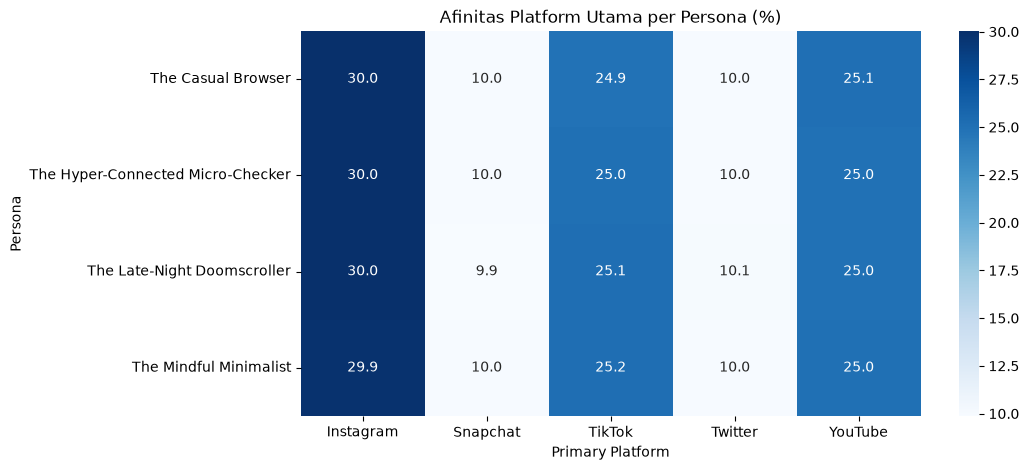

In [21]:
# 1. Ambil kolom primary_platform langsung dari file Parquet
df_features['primary_platform'] = conn.execute("""
    SELECT primary_platform 
    FROM '../data/raw/genz_social_media_usage_1M.parquet'
""").df()['primary_platform']

# 2. Hitung proporsi platform utama di tiap persona
platform_crosstab = pd.crosstab(
    df_features['persona'], 
    df_features['primary_platform'], 
    normalize='index'
).mul(100).round(2)

# 3. Visualisasikan Heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(platform_crosstab, annot=True, cmap='Blues', fmt='.1f')
plt.title("Afinitas Platform Utama per Persona (%)")
plt.ylabel("Persona")
plt.xlabel("Primary Platform")
plt.show()

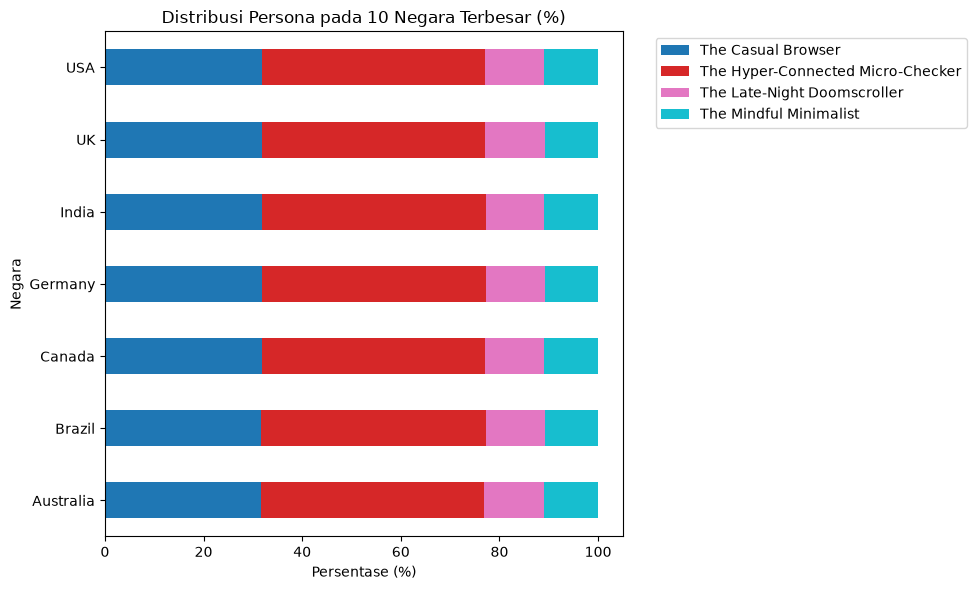

In [22]:
# Ambil 10 negara dengan volume pengguna terbanyak
top_countries = df_features['country'].value_counts().head(10).index
country_df = df_features[df_features['country'].isin(top_countries)]

# Distribusi persona per negara
country_persona = pd.crosstab(
    country_df['country'], 
    country_df['persona'], 
    normalize='index'
).mul(100).round(2)

country_persona.plot(kind='barh', stacked=True, figsize=(10, 6), colormap='tab10')
plt.title("Distribusi Persona pada 10 Negara Terbesar (%)")
plt.xlabel("Persentase (%)")
plt.ylabel("Negara")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [23]:
import joblib
import os

os.makedirs('../models', exist_ok=True)
joblib.dump(kmeans, '../models/kmeans_k4.joblib')
joblib.dump(scaler, '../models/scaler.joblib')
print("Model dan Scaler berhasil disimpan di folder models/")

Model dan Scaler berhasil disimpan di folder models/
